In [1]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
mpl.rcParams['figure.dpi'] = 72

In [ ]:
# source = "scream"
# source = "nicam_gl11"
# source = "um_glm_n2560_RAL3p3"
# source = "icon_d3hp003"
# source = "ifs_tco3999_rcbmf"
source = "casesm2_10km_nocumulus"
# source = "IMERGv7"

# # MCS masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/mcs_masks/"
# in_zarr = f"{root_dir}{source}_mcs_masks_hp8.zarr"
# in_zarr

# Combined all feature masks
root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
in_zarr = f"{root_dir}{source}_allmasks_hp8_v1.zarr"
in_zarr

'/pscratch/sd/w/wcmca1/hackathon/mcs_masks/casesm2_10km_nocumulus_mcs_masks_hp8.zarr'

In [13]:
ds = xr.open_zarr(in_zarr, consolidated=True)
ds

<xarray.Dataset> Size: 5GB
Dimensions:   (cell: 786432, time: 1461)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    crs       int64 8B ...
  * time      (time) datetime64[ns] 12kB 2020-03-01 ... 2021-03-01
Data variables:
    mcs_mask  (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
Attributes: (12/18)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Fri Jul 18 10:34:12 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    processing_script:         make_mcs_swath_masks.py
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [14]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2020-03-01T00:00:00.000000000', '2020-03-01T06:00:00.000000000',
       '2020-03-01T12:00:00.000000000', '2020-03-01T18:00:00.000000000',
       '2020-03-02T00:00:00.000000000', '2020-03-02T06:00:00.000000000',
       '2020-03-02T12:00:00.000000000', '2020-03-02T18:00:00.000000000',
       '2020-03-03T00:00:00.000000000', '2020-03-03T06:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    crs      int64 8B ...
  * time     (time) datetime64[ns] 80B 2020-03-01 ... 2020-03-03T06:00:00
Attributes:
    long_name:  Base time in Epoch

<Figure size 460.8x345.6 with 0 Axes>

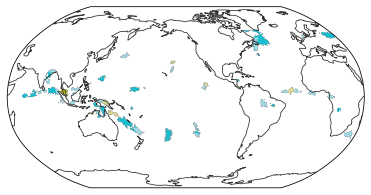

In [15]:
itime = 1021
mcs_mask = ds.mcs_mask.isel(time=itime)
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

In [16]:
sdate = '2020-03-01T00'
edate = '2020-03-31T23'

mcs_binary = ds.mcs_mask.sel(time=slice(sdate, edate)) > 0
mcs_count = mcs_binary.sum(dim='time')
nhours = ds.time.sel(time=slice(sdate, edate)).count()

mcs_freq = 100 * mcs_count / nhours

<Figure size 460.8x345.6 with 0 Axes>

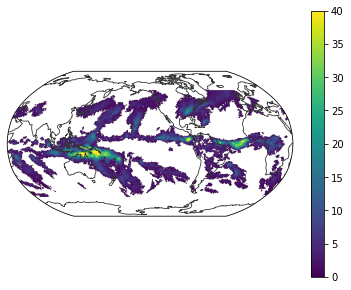

In [17]:
img = egh.healpix_show(mcs_freq.where(mcs_freq > 0), vmin=0, vmax=40)
plt.colorbar(img)

In [8]:
mcs_freq.max().values

array(83.87096774)